# KDD Cup 2012 — Ad Clickthrough Rate: Exploratory Data Analysis

**Objective:** Explore the KDD Cup 2012 Track 2 dataset to identify the factors that influence ad clickthrough rate (CTR), including ad position, session depth, user demographics, advertiser behaviour, and query characteristics.

**Dataset:** KDD Cup 2012, Track 2 — Tencent sponsored search advertising (~5 million training records)
**Source:** [Kaggle KDD Cup 2012 Track 2](https://www.kaggle.com/c/kddcup2012-track2)

**Author:** Ayush Singh

## Objective

# 1. Business Problem

## 1.1 Problem Description

__ Introduction: 
 Clickthrough rate (CTR) __
is a ratio showing how often people who see your ad end up clicking it. Clickthrough rate (CTR) can be used to gauge how well your keywords and ads are performing.

- CTR is the number of clicks that your ad receives divided by the number of times your ad is shown: clicks ÷ impressions = CTR. For example, if you had 5 clicks and 100 impressions, then your CTR would be 5%.

- Each of your ads and keywords have their own CTRs that you can see listed in your account.
- A high CTR is a good indication that users find your ads helpful and relevant. CTR also contributes to your keyword's expected CTR, which is a component of Ad Rank. Note that a good CTR is relative to what you're advertising and on which networks.
> Credits: Google (https://support.google.com/adwords/answer/2615875?hl=en) 

 Search advertising has been one of the major revenue sources of the Internet industry for years. A key technology behind search advertising is to predict the click-through rate (pCTR) of ads, as the economic model behind search advertising requires pCTR values to rank ads and to price clicks.** In this task, given the training instances derived from session logs of the Tencent proprietary search engine, soso.com, participants are expected to accurately predict the pCTR of ads in the testing instances. **

## 1.2 Source/Useful Links

__ Source __ : https://www.kaggle.com/c/kddcup2012-track2 

## 1.3 Real-world/Business Objectives and Constraints

Objective: Predict the pClick (probability of click) as accurately as possible.

Constraints: Low latency, Interpretability.

## Dataset Description

The KDD Cup 2012 dataset comes from Tencent's sponsored search system and records how users interact with search ads. Each training row represents one (user, query, ad) triple, with the number of clicks and impressions over a reporting period. The data spans multiple relational files that must be joined to form a complete feature set.

# 2. Machine Learning problem

## 2.1 Data

### 2.1.1 Data Overview

___
There are five additional data files, as mentioned in the above section: 

1. queryid_tokensid.txt 

2. purchasedkeywordid_tokensid.txt 

3. titleid_tokensid.txt 

4. descriptionid_tokensid.txt 

5. userid_profile.txt 

Each line of the first four files maps an id to a list of tokens, corresponding to the query, keyword, ad title, and ad description, respectively. In each line, a TAB character separates the id and the token set.  A token can basically be a word in a natural language. For anonymity, each token is represented by its hash value.  Tokens are delimited by the character ‘|’. 

Each line of ‘userid_profile.txt’ is composed of UserID, Gender, and Age, delimited by the TAB character. Note that not every UserID in the training and the testing set will be present in ‘userid_profile.txt’. Each field is described below: 

1. Gender:  '1'  for male, '2' for female,  and '0'  for unknown. 

2. Age: '1'  for (0, 12],  '2' for (12, 18], '3' for (18, 24], '4'  for  (24, 30], '5' for (30,  40], and '6' for greater than 40.

### 2.1.2 Example Data point

__ training.txt __
```
Click Impression	AdURL	     AdId	   AdvId  Depth	Pos	 QId	   KeyId	TitleId	 DescId	 UId
0	 1	 4298118681424644510	7686695	385	    3	  3	 1601	    5521	 7709	  576	 490234
0	 1	 4860571499428580850	21560664	37484	  2	  2	 2255103	317	     48989	  44771	 490234
0	 1	 9704320783495875564	21748480	36759	  3	  3	 4532751	60721	 685038	  29681	 490234
```

__ queryid_tokensid.txt__
```
QId	Query
0	12731
1	1545|75|31
2	383
3	518|1996
4	4189|75|31
```

__purchasedkeywordid_tokensid.txt__
```

```

__titleid_tokensid.txt__
```
TitleId	Title
0	615|1545|75|31|1|138|1270|615|131
1	466|582|685|1|42|45|477|314
2	12731|190|513|12731|677|183
3	2371|3970|1|2805|4340|3|2914|10640|3688|11|834|3
4	165|134|460|2887|50|2|17527|1|1540|592|2181|3|...
```

__descriptionid_tokensid.txt__
```
DescId	Description
0	1545|31|40|615|1|272|18889|1|220|511|20|5270|1...
1	172|46|467|170|5634|5112|40|155|1965|834|21|41...
2	2672|6|1159|109662|123|49933|160|848|248|207|1...
3	13280|35|1299|26|282|477|606|1|4016|1671|771|1...
4	13327|99|128|494|2928|21|26500|10|11733|10|318
```

__userid_profile.txt__
```
UId	Gender	Age
1	1	5
2	2	3
3	1	5
4	1	3
5	2	1
```

## 2.2 Mapping the Real-world to a Machine Learning problem

### 2.2.1 Type of Machine Learning Problem

It is a regression problem as we predicting CTR = #clicks/#impressions

### 2.2.2 Performance metric

Souce : https://www.kaggle.com/c/kddcup2012-track2#Evaluation 

ROC: https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/receiver-operating-characteristic-curve-roc-curve-and-auc-1/

### 2.2.3 Machine Learning Objectives and Constraints

...

## Loading & Merging Data

The dataset lives in five separate files: the training log (click and impression counts), user profiles (gender and age), query tokens, ad title tokens, and ad description tokens. We join all five on their respective IDs to produce a single analysis-ready dataframe. Tokens are stored as pipe-delimited IDs rather than raw text, so we convert each text field to a word count before dropping the raw column.

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Tab-separated with no header row — we name columns to match the KDD competition schema.
column = ['Click', 'Impression', 'AdURL', 'AdId', 'AdvId', 'Depth', 'Pos', 'QId', 'KeyId', 'TitleId', 'DescId', 'UId']
orignal = pd.read_csv('track2/training.txt', sep='\t', header=None, nrows=5000000, names=column)
orignal.head()

,Click,Impression,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,DescId,UId
0,0,1,4298118681424644510,7686695,385,3,3,1601,5521,7709,576,490234
1,0,1,4860571499428580850,21560664,37484,2,2,2255103,317,48989,44771,490234
2,0,1,9704320783495875564,21748480,36759,3,3,4532751,60721,685038,29681,490234
3,0,1,13677630321509009335,3517124,23778,3,1,1601,2155,1207,1422,490234
4,0,1,3284760244799604489,20758093,34535,1,1,4532751,77819,266618,222223,490234


In [3]:
# User profile maps UIDs to gender and age group.
# Joined to training data later to study whether demographics shift CTR.
user_col = ['UId', 'Gender', 'Age']
user = pd.read_csv('track2/userid_profile.txt', sep='\t', header=None, names=user_col)
user.head()

,UId,Gender,Age
0,1,1,5
1,2,2,3
2,3,1,5
3,4,1,3
4,5,2,1


In [4]:
# Queries are stored as pipe-separated token IDs rather than raw text (privacy/compression).
# We'll derive word count as a proxy for query complexity.
query_col = ['QId', 'Query']
query = pd.read_csv('track2/queryid_tokensid.txt', sep='\t', header=None, names=query_col)
query.head(5)

,QId,Query
0,0,12731
1,1,1545|75|31
2,2,383
3,3,518|1996
4,4,4189|75|31


In [5]:
# Ad descriptions are token sequences. Word count captures descriptive richness without raw text.
desc_col = ['DescId', 'Description']
desc = pd.read_csv('track2/descriptionid_tokensid.txt', sep='\t', header=None, names=desc_col)
desc.head(5)

,DescId,Description
0,0,1545|31|40|615|1|272|18889|1|220|511|20|5270|1...
1,1,172|46|467|170|5634|5112|40|155|1965|834|21|41...
2,2,2672|6|1159|109662|123|49933|160|848|248|207|1...
3,3,13280|35|1299|26|282|477|606|1|4016|1671|771|1...
4,4,13327|99|128|494|2928|21|26500|10|11733|10|318...


In [6]:
# Ad titles are also token sequences — word count is our usable signal from this field.
title_col = ['TitleId', 'Title']
title = pd.read_csv('track2/titleid_tokensid.txt', sep='\t', header=None, names=title_col)
title.head(5)

,TitleId,Title
0,0,615|1545|75|31|1|138|1270|615|131
1,1,466|582|685|1|42|45|477|314
2,2,12731|190|513|12731|677|183
3,3,2371|3970|1|2805|4340|3|2914|10640|3688|11|834|3
4,4,165|134|460|2887|50|2|17527|1|1540|592|2181|3|...


In [7]:
# Tokens are pipe-delimited ('|') in this dataset, so we split on '|' rather than space.
# Word count is a simple but effective proxy for content length across all text fields.
def count(sentence):
    return len(str(sentence).split('|'))

In [8]:
# Longer queries may indicate more specific intent, which could suppress or boost CTR depending on match quality.
query['QCount'] = query['Query'].apply(count)

In [9]:
query.head(5)

,QId,Query,QCount
0,0,12731,1
1,1,1545|75|31,3
2,2,383,1
3,3,518|1996,2
4,4,4189|75|31,3


In [10]:
# Drop raw token column — we only need the count; keeping raw tokens would bloat memory during the merge.
del query['Query']
query.head()

,QId,QCount
0,0,1
1,1,3
2,2,1
3,3,2
4,4,3


In [11]:
# Longer ad titles may provide more context but trade off visual clarity.
title['TCount'] = title['Title'].apply(count)

In [12]:
title.head()

,TitleId,Title,TCount
0,0,615|1545|75|31|1|138|1270|615|131,9
1,1,466|582|685|1|42|45|477|314,8
2,2,12731|190|513|12731|677|183,6
3,3,2371|3970|1|2805|4340|3|2914|10640|3688|11|834|3,12
4,4,165|134|460|2887|50|2|17527|1|1540|592|2181|3|...,16


In [13]:
# Drop raw token column after deriving the count.
del title['Title']
title.head()

,TitleId,TCount
0,0,9
1,1,8
2,2,6
3,3,12
4,4,16


In [14]:
# Longer ad descriptions may build user trust and improve CTR — or just add noise.
desc['DCount'] = desc['Description'].apply(count)

In [15]:
desc.head()

,DescId,Description,DCount
0,0,1545|31|40|615|1|272|18889|1|220|511|20|5270|1...,20
1,1,172|46|467|170|5634|5112|40|155|1965|834|21|41...,28
2,2,2672|6|1159|109662|123|49933|160|848|248|207|1...,21
3,3,13280|35|1299|26|282|477|606|1|4016|1671|771|1...,25
4,4,13327|99|128|494|2928|21|26500|10|11733|10|318...,17


In [16]:
# Drop raw token column after deriving the count.
del desc['Description']
desc.head()

,DescId,DCount
0,0,20
1,1,28
2,2,21
3,3,25
4,4,17


In [17]:
# Inner-join on all four keys to assemble the analysis-ready dataframe.
# Some rows will be lost where user profile entries are missing — this is expected and minor.
data = pd.merge(orignal, user,  on='UId')
data = pd.merge(data,    query, on='QId')
data = pd.merge(data,    title, on='TitleId')
data = pd.merge(data,    desc,  on='DescId')

In [18]:
data.head()

,Click,Impression,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,DescId,UId,Gender,Age,QCount,TCount,DCount
0,0,1,4298118681424644510,7686695,385,3,3,1601,5521,7709,576,490234,1,3,1,8,21
1,0,1,4860571499428580850,21560664,37484,2,2,2255103,317,48989,44771,490234,1,3,2,10,22
2,0,1,9704320783495875564,21748480,36759,3,3,4532751,60721,685038,29681,490234,1,3,3,6,24
3,0,1,13677630321509009335,3517124,23778,3,1,1601,2155,1207,1422,490234,1,3,1,5,20
4,0,1,3284760244799604489,20758093,34535,1,1,4532751,77819,266618,222223,490234,1,3,3,9,24


In [19]:
# CTR = clicks / impressions * 100. This is the target variable — what we want to predict.
# Multiplying by 100 gives percentage form, which is more readable in plots and summary stats.
data['CTR'] = data['Click'] * 1.0 / data['Impression'] * 100
data.head()

,Click,Impression,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,DescId,UId,Gender,Age,QCount,TCount,DCount,CTR
0,0,1,4298118681424644510,7686695,385,3,3,1601,5521,7709,576,490234,1,3,1,8,21,0.0
1,0,1,4860571499428580850,21560664,37484,2,2,2255103,317,48989,44771,490234,1,3,2,10,22,0.0
2,0,1,9704320783495875564,21748480,36759,3,3,4532751,60721,685038,29681,490234,1,3,3,6,24,0.0
3,0,1,13677630321509009335,3517124,23778,3,1,1601,2155,1207,1422,490234,1,3,1,5,20,0.0
4,0,1,3284760244799604489,20758093,34535,1,1,4532751,77819,266618,222223,490234,1,3,3,9,24,0.0


In [20]:
# Verify row count post-merge — drop from 5M to ~4.95M is expected due to missing user profiles.
data.shape

(4952274, 18)

Note: We loaded 5M datapoints initially, after merger we have around 4.95M datapoints. What does this indicate ? Actually for a lot of user ids data is missing hence merge operation gets rid of such datapoints.

## CTR Distribution Analysis

The dataset-level CTR is approximately 4.2% — ad clicks are relatively rare events. Before building predictive features, we examine how query length, ad description length, and ad title length relate to CTR. We also check whether ads with more impressions automatically attract more clicks. These patterns tell us which textual features carry signal and which are mostly noise.

In [21]:
# Compute dataset-level CTR first to establish a baseline before any feature-level breakdown.
# This single number shows how rare clicks are overall — context for interpreting all downstream plots.
total_impressions = data['Impression'].sum()
total_clicks = data['Click'].sum()
net_CTR = total_clicks * 1.0 / total_impressions
print('Net CTR: {0} %'.format(round(net_CTR * 100, 2)))

Net CTR: 4.2 %


In [22]:
total = data.shape[0]

In [23]:
# Many unique users means limited per-user click history — important context for feature sparsity later.
print('Total no. of unique users:', len(data.groupby('UId')))

Total no. of unique users: 971492


In [24]:
# Unique query count: high diversity means each query appears rarely, limiting query-level CTR estimates.
print('Total no. of unique queries:', len(data.groupby('QId')))

Total no. of unique queries: 1155690


In [25]:
# Many unique ads means most ads have few impressions — sparse click history motivates smoothed CTR features.
print('Total no. of unique ads:', len(data.groupby('AdId')))

Total no. of unique ads: 212422


In [26]:
# Unique advertiser count: fewer unique advertisers than ads means advertisers run multiple creatives.
print('Total no. of unique advertisers:', len(data.groupby('AdvId')))

Total no. of unique advertisers: 13921


In [27]:
# Check query length range before visualizing — extreme outliers can compress the visible distribution.
temp = data[['QCount']].copy()
print('Maximum Length of a Query: ', temp['QCount'].max())
print('Average Length of a Query: ', temp['QCount'].mean())

Maximum Length of a Query:  127
Average Length of a Query:  2.9885535412620547


<Axes: ylabel='QCount'>

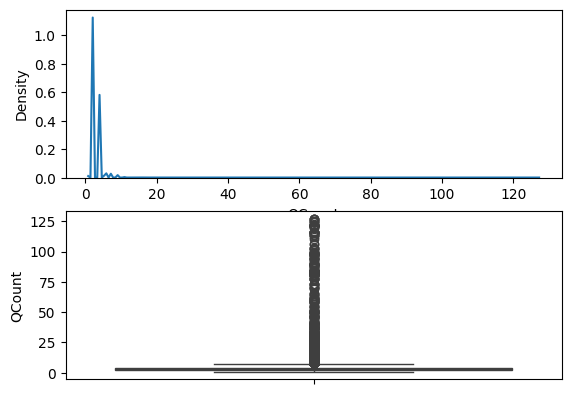

In [28]:
# KDE shows the smooth continuous shape; boxplot reveals skew and outlier extent side-by-side.
# Using both together is more informative than either alone for skewed count distributions.
f, (ax1, ax2) = plt.subplots(2)
sns.kdeplot(temp['QCount'], ax=ax1)
sns.boxplot(x=None, y='QCount', data=temp, ax=ax2)

Clearly, data contains outliers. We will remove them in order to make our analysis more robust.

In [29]:
print('Avg No. of words in a Search query:', round(temp['QCount'].mean(), 2))
print('Median No. of words in a Search query:', temp['QCount'].quantile(0.5))
print('3rd Quantile No. of words in a Search query:', temp['QCount'].quantile(0.75))

Avg No. of words in a Search query: 2.99
Median No. of words in a Search query: 3.0
3rd Quantile No. of words in a Search query: 4.0


In [30]:
# Cap at 10 words — 99.5% of queries fall below this threshold (confirmed below), so almost no data is lost.
# This removes long-tail outliers that would compress the histogram and hide the true distribution shape.
temp = temp[temp['QCount'] < 10.0]
print('Maximum Length of a Query: ', temp['QCount'].max())
print('Average Length of a Query: ', temp['QCount'].mean())

Maximum Length of a Query:  9
Average Length of a Query:  2.9498189918903743


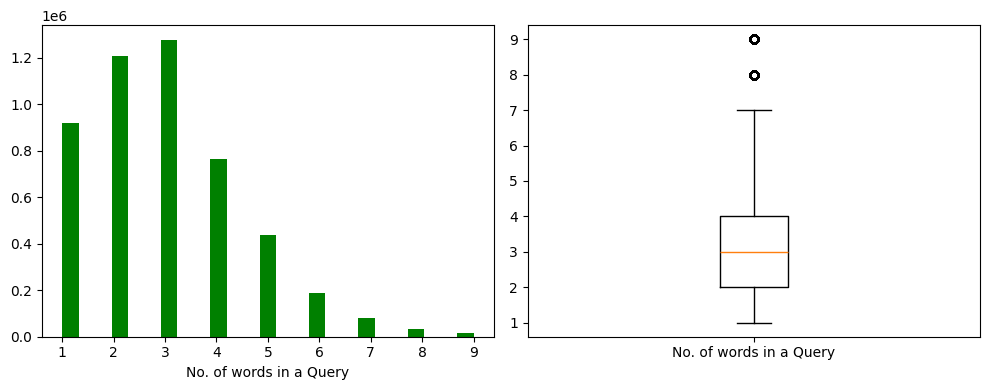

In [31]:
# Re-plot after outlier removal — histogram and boxplot now show the true distribution clearly.
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(temp['QCount'], color='green', bins=25)
plt.xlabel('No. of words in a Query')

plt.subplot(1, 2, 2)
plt.boxplot(temp['QCount'], tick_labels=['No. of words in a Query'])

plt.tight_layout()

Conclusion: 

75% of search queries have 4 words or fewer
(the 75th percentile sits exactly at 4.0).

In [32]:
# Ad description length: check range before plotting to decide whether outlier removal is needed.
temp = data[['DCount']].copy()
print('Maximum Length of an Ad Description: ', temp['DCount'].max())
print('Average Length of an Ad Description: ', temp['DCount'].mean())

Maximum Length of an Ad Description:  47
Average Length of an Ad Description:  21.311864812003535


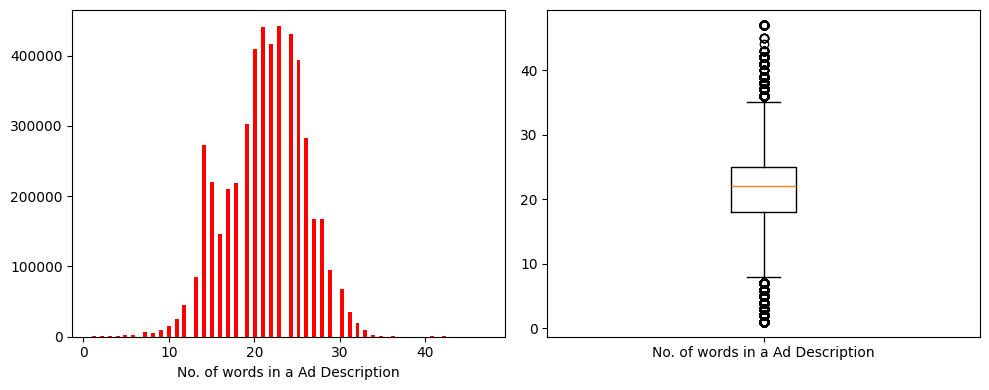

In [33]:
# Histogram with boxplot — description lengths are less skewed than query lengths so no outlier removal needed.
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(temp['DCount'], bins=100, color='red', density=False)
plt.xlabel('No. of words in a Ad Description')
plt.subplot(1, 2, 2)
plt.boxplot(temp['DCount'], labels=['No. of words in a Ad Description'])
plt.tight_layout()

In [34]:
print('Median No. of words in a Ad description:', temp['DCount'].quantile(0.5))
print('3rd Quantile No. of words in a Ad description:', temp['DCount'].quantile(0.75))

Median No. of words in a Ad description: 22.0
3rd Quantile No. of words in a Ad description: 25.0


Conclusion:

75 % of the Ads use <= 25.0 words for Ad description.

In [35]:
# Ad title lengths: shorter than descriptions on average — most titles are a few tokens.
temp = data[['TCount']].copy()
print('Maximum Length of an Ad Title: ', temp['TCount'].max())
print('Average Length of an Ad Title: ', temp['TCount'].mean())

Maximum Length of an Ad Title:  32
Average Length of an Ad Title:  8.765298931359613


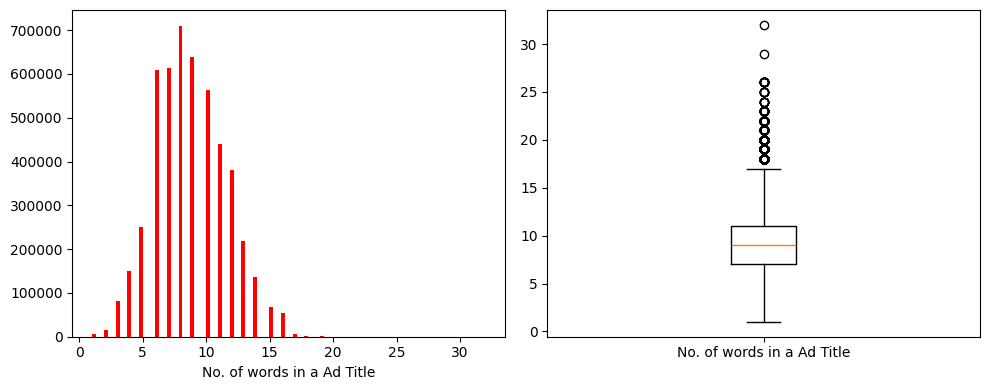

In [36]:
# Using 100 bins to show fine-grained distribution of short token sequences.
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(temp['TCount'], color='red', bins=100, density=False)
plt.xlabel('No. of words in a Ad Title')
plt.subplot(1, 2, 2)
plt.boxplot(temp['TCount'], labels=['No. of words in a Ad Title'])
plt.tight_layout()

In [37]:
print('Median No. of words in a Ad title:', temp['TCount'].quantile(0.5))
print('3rd Quantile No. of words in a Ad title:', temp['TCount'].quantile(0.75))

Median No. of words in a Ad title: 9.0
3rd Quantile No. of words in a Ad title: 11.0


Conclusion:

75 % of the Ads use < = 11.0 words in their Ad titles.

In [38]:
# Test if query complexity (word count) correlates with ad CTR.
# Longer queries might mean more specific intent — but the ad may match less well, suppressing CTR.
temp = data[['QCount', 'CTR']].copy()
temp.head()

,QCount,CTR
0,1,0.0
1,2,0.0
2,3,0.0
3,1,0.0
4,3,0.0


In [39]:
# Consistent with our earlier outlier cap — keeps the same 99.5% of data for a fair comparison.
temp = temp[temp['QCount'] < 10.0]

In [40]:
temp.shape[0] * 1.0 / data.shape[0]  # confirms >99% of data is retained after this filter

0.9958146499971529

In [41]:
# Average CTR per query length — groupby-agg collapses individual rows into per-length statistics.
result = temp.groupby('QCount').agg(['mean'])
result.head()

,CTR
,mean
QCount,
1,3.707213
2,4.868142
3,4.902491
4,4.597467
5,4.271822


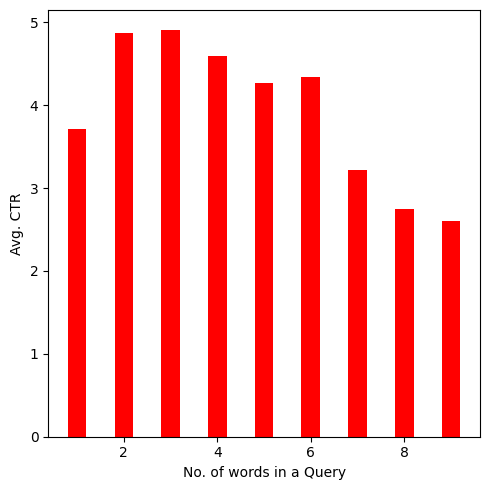

In [42]:
plt.figure(figsize=(5, 5))
plt.bar(result.index, result[('CTR', 'mean')], color='red', width=0.4)
plt.xlabel('No. of words in a Query')
plt.ylabel('Avg. CTR')
plt.tight_layout()

Conclusion: CTR peaks at 3-word queries (4.90%) and declines for longer queries. Single-word queries also underperform (3.71%) — suggesting that very short queries are too ambiguous and very long queries are too specific to match ads effectively.

In [43]:
# Test if longer ad descriptions correlate with higher CTR — more copy might mean more persuasive ads.
temp = data[['DCount', 'CTR']].copy()

In [44]:
temp[temp['DCount'] >= 40.0].shape[0] * 1.0 / data.shape[0]  # only 0.02% use >= 40 words — long tail is negligible

0.00029178514759078353

In [45]:
result = temp.groupby('DCount').agg(['mean'])
result.head()

,CTR
,mean
DCount,
1,1.204819
2,2.987421
3,3.093812
4,6.115780
5,4.799375


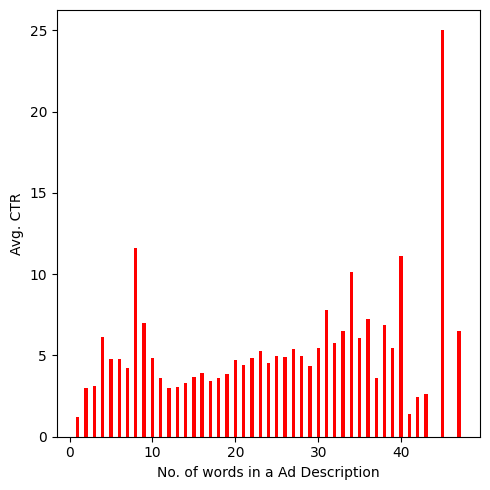

In [46]:
plt.figure(figsize=(5, 5))
plt.bar(result.index, result[('CTR', 'mean')], color='red', width=0.4)
plt.xlabel('No. of words in a Ad Description')
plt.ylabel('Avg. CTR')
plt.tight_layout()

Conclusion: No. of words in Ad description doesn't give a clear picture of Ad CTR.

In [47]:
# Test if title length affects CTR — very short or very long titles might reduce readability and clicks.
temp = data[['TCount', 'CTR']].copy()

In [48]:
temp[temp['TCount'] >= 25.0].shape[0] * 1.0 / data.shape[0]  # only 0.0005% use >= 25 words in title

5.452040820035402e-06

In [49]:
result = temp.groupby('TCount').agg(['mean'])
result.head()

,CTR
,mean
TCount,
1,5.188903
2,5.468239
3,4.382002
4,4.484546
5,4.361038


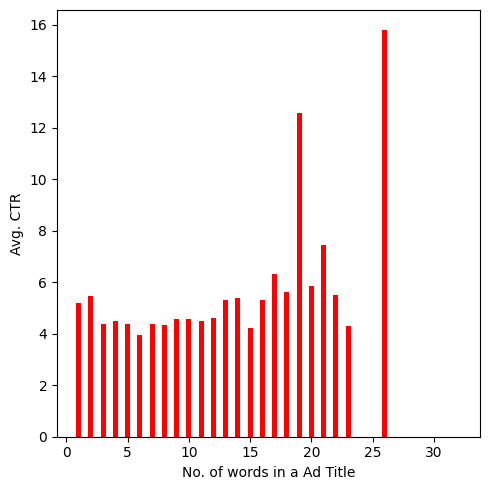

In [50]:
plt.figure(figsize=(5, 5))
plt.bar(result.index, result[('CTR', 'mean')], color='red', width=0.4)
plt.xlabel('No. of words in a Ad Title')
plt.ylabel('Avg. CTR')
plt.tight_layout()

Conclusion: Avg. Ad CTR is more or less distributed uniformly with no. of words in Ad title.

In [51]:
# Scatter: impressions vs clicks per ad — tests if more exposure directly translates to more clicks.
# If so, impression count is a confound we need to account for in the model.
temp = data[['AdId', 'Impression', 'Click']].copy()
temp.head()

,AdId,Impression,Click
0,7686695,1,0
1,21560664,1,0
2,21748480,1,0
3,3517124,1,0
4,20758093,1,0


In [52]:
# Average impressions and clicks per ad across all its training rows.
result = temp.groupby('AdId').agg(['mean'])
result.head(6)

,Impression,Click
,mean,mean
AdId,,
1000031,1.000000,0.000000
1000467,2.315789,0.105263
1000468,1.000000,0.000000
1000469,1.000000,0.000000
1000471,1.000000,0.000000
1000473,2.000000,0.000000


Text(0.5, 1.0, 'Relationship between Ad Impressions & Clicks')

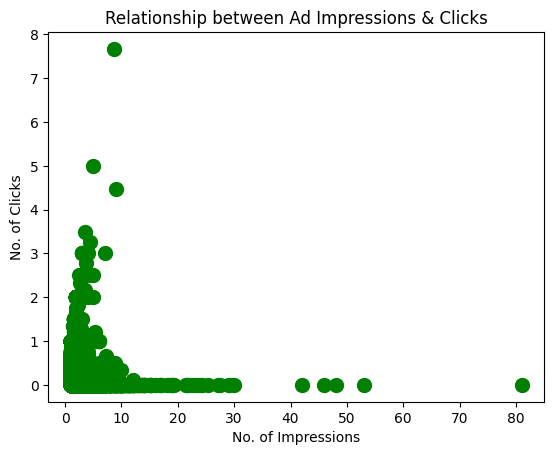

In [53]:
x = result[('Impression', 'mean')]
y = result[('Click', 'mean')]
plt.scatter(x, y, c='green', s=100, marker='o', edgecolor=None)
plt.xlabel('No. of Impressions')
plt.ylabel('No. of Clicks')
plt.title('Relationship between Ad Impressions & Clicks')

Conclusion: As no. of impressions of an advertisement inc. clicks are mostly ~ 0.

This indicates a very crucial aspect of human behaviour. As a user see the same ad again & again, they are less likely to click it.

## User Demographics (Age/Gender)

Query length and ad text length showed modest or no consistent CTR signal. We now turn to the user side. Tencent's platform records user gender and age group. We test whether either variable differentiates clickers from non-clickers, and then drill into whether older users and female users interact differently — checking for an age × gender interaction effect.

In [54]:
# Test if user gender differentiates clickers — if it does, it becomes a useful personalization feature.
temp = data[['Gender', 'CTR']].copy()
temp.head()

,Gender,CTR
0,1,0.0
1,1,0.0
2,1,0.0
3,1,0.0
4,1,0.0


In [55]:
# Average CTR by gender code.
result = temp.groupby('Gender').agg(['mean'])
result.head()

,CTR
,mean
Gender,
0,4.527559
1,4.409308
2,4.585996


In [56]:
# Gender encoding in this dataset: 1 = Male, 2 = Female, 0 = Unknown

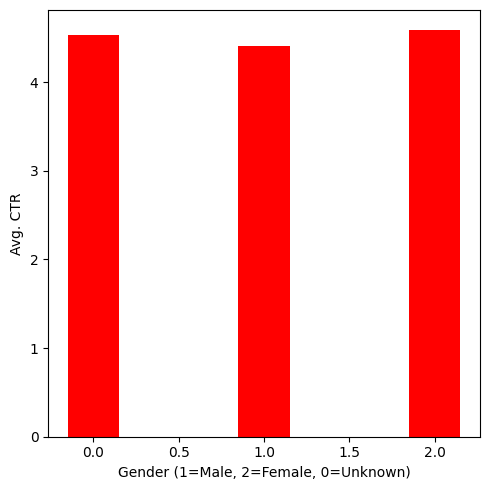

In [57]:
plt.figure(figsize=(5, 5))
plt.bar(result.index, result[('CTR', 'mean')], color='red', width=0.3)
plt.xlabel('Gender (1=Male, 2=Female, 0=Unknown)')
plt.ylabel('Avg. CTR')
plt.tight_layout()

Conclusion: Gender of a user doesn't impact CTR of an advertisement.

In [58]:
# Test if age group correlates with CTR — older users may have more purchasing intent.
temp = data[['Age', 'CTR']].copy()
temp.head()

,Age,CTR
0,3,0.0
1,3,0.0
2,3,0.0
3,3,0.0
4,3,0.0


In [59]:
temp[temp['Age'] > 4.0].shape[0] * 1.0 / data.shape[0]  # 21% of data is in age groups 5 and 6 (older users)

0.21332624164171854

In [60]:
result = temp.groupby('Age').agg(['mean'])
result.head(6)

,CTR
,mean
Age,
1,4.457391
2,4.525747
3,4.384555
4,4.232053
5,4.746470
6,5.256566


In [61]:
# Age group legend (KDD-defined buckets, not our choice):
# 1: 0-12,  2: 12-18,  3: 18-24,  4: 24-30,  5: 30-40,  6: >40

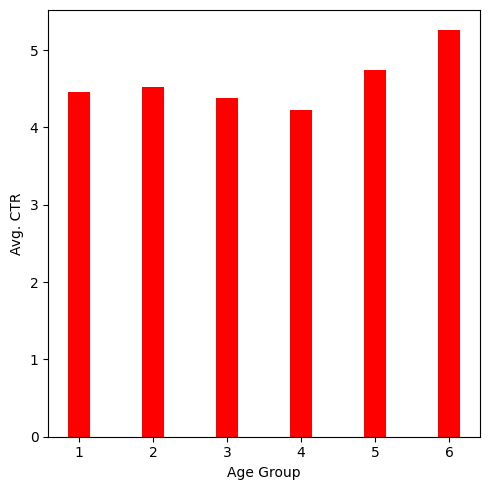

In [62]:
plt.figure(figsize=(5, 5))
plt.bar(result.index, result[('CTR', 'mean')], color='red', width=0.3)
plt.xlabel('Age Group')
plt.ylabel('Avg. CTR')
plt.tight_layout()

Conclusion: An user in categories 5 & 6 has higher avg. CTR as compared to users in other categories.

In [63]:
# Drill down: among older users (age 5 & 6) who show higher CTR, does gender further differentiate?
# This tests for an interaction effect between age and gender — marginal analysis of gender alone missed this.
temp = data[['Gender', 'Age', 'CTR']].copy()
temp = temp[(temp['Age'] == 5) | (temp['Age'] == 6)]
temp.head()

,Gender,Age,CTR
164,1,5,0.0
165,1,5,0.0
166,1,5,0.0
167,1,5,100.0
168,1,5,0.0


In [64]:
temp[temp['Gender'] == 2.0].shape[0] * 1.0 / data.shape[0]  # older female users are ~9.3% of total dataset

0.09328482228568129

In [65]:
temp = temp[['Gender', 'CTR']].copy()
result = temp.groupby('Gender').agg(['mean'])
result.head()

,CTR
,mean
Gender,
0,4.277570
1,4.808067
2,5.025482


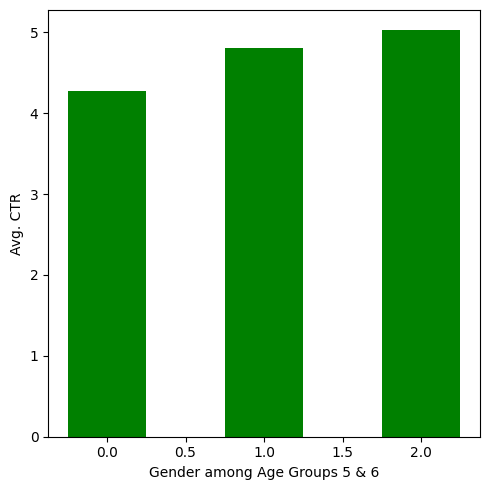

In [66]:
plt.figure(figsize=(5, 5))
plt.bar(result.index, result[('CTR', 'mean')], color='green', width=0.5)
plt.xlabel('Gender among Age Groups 5 & 6')
plt.ylabel('Avg. CTR')
plt.tight_layout()

Conclusion: Female users (2) in Age categories 5 & 6 are more likely to click an Ad as opposed to their male (1) counterparts.

## Ad Position & Depth Effects

Demographics offer limited CTR signal on their own. We now examine structural features of the ad placement itself: ad position within the results page, and session depth (how many ads were shown in the session). Both are strong candidate features for the model because they reflect the user's attention state at the moment of exposure.

In [67]:
# Ad position directly controls visibility — position 1 is at the top of the page.
# This is one of the most important structural features for CTR prediction.
temp = data[['Pos', 'CTR']].copy()
temp.head()

,Pos,CTR
0,3,0.0
1,2,0.0
2,3,0.0
3,1,0.0
4,1,0.0


In [68]:
# Aggregate both mean CTR and count per position.
# Count shows how often each position appears — needed to judge whether the CTR difference is robust.
result = temp.groupby('Pos').agg(['mean', 'count'])
result.head()

CTR         
         mean    count
Pos                   
1    5.518009  3022771
2    3.077325  1597657
3    1.894403   331846

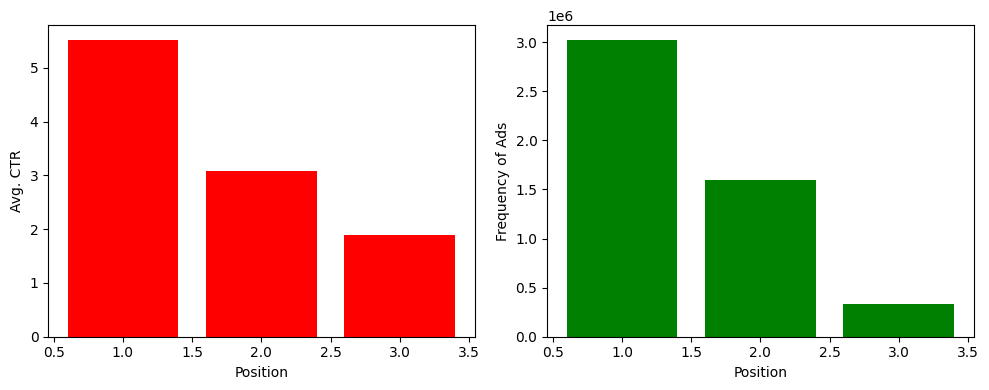

In [69]:
# Left panel: average CTR by position. Right panel: ad frequency by position.
# Comparing both reveals whether position-1 CTR advantage is consistent or driven by volume effects.
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(result.index, result[('CTR', 'mean')], color='red')
plt.xlabel('Position')
plt.ylabel('Avg. CTR')
plt.subplot(1, 2, 2)
plt.bar(result.index, result[('CTR', 'count')], color='green')
plt.xlabel('Position')
plt.ylabel('Frequency of Ads')
plt.tight_layout()

Conclusion: Clearly, the CTR for an advertisement which has a low position (more visible to user) is higher as compared to CTR of an advertisement with higher position(not directly visible).

Typically advertisement have lower position. [1,2]

In [70]:
# Session depth = number of ads shown in the session.
# We expect CTR to fall with depth as user attention and intent diminish over the session.
temp = data[['Depth', 'CTR']].copy()
temp.head()

,Depth,CTR
0,3,0.0
1,2,0.0
2,3,0.0
3,3,0.0
4,1,0.0


In [71]:
result = temp.groupby('Depth').agg(['mean', 'count'])
result.head()

CTR         
           mean    count
Depth                   
1      4.577864  1450766
2      4.799309  2514678
3      3.561618   986830

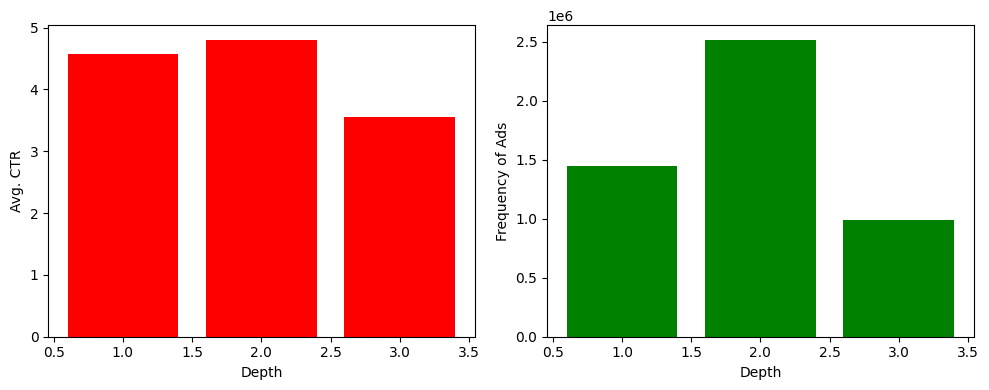

In [72]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(result.index, result[('CTR', 'mean')], color='red')
plt.xlabel('Depth')
plt.ylabel('Avg. CTR')
plt.subplot(1, 2, 2)
plt.bar(result.index, result[('CTR', 'count')], color='green')
plt.xlabel('Depth')
plt.ylabel('Frequency of Ads')
plt.tight_layout()
plt.show()

Conclusion: 

1. Mostly depth of a Search Session is 2.
2. If depth if high (3) avg. CTR falls. This means if there as no. of ads in a Search Session inc. avg. CTR dec.

## Advertiser & Query Patterns

Position and depth are strong placement signals. Now we shift to the advertiser level: do some advertisers consistently attract more clicks regardless of where their ads appear? We split advertisers into high-CTR vs low-CTR groups (using the 3rd quartile as the threshold) and compare their ad copy length and impression volume. We then repeat the frequency analysis to see whether heavier ad buyers also earn higher CTRs.

We divide the data into two categories, one corr. to Advertisers who have a high CTR on their Ads & other who don't.
Once we know who are the Advertisers with high CTR Ads, we can study how Ads by a high CTR Adv. differs from a Adv.
with low CTR Ads.
e.g. We can know if an advertiser with high CTR ads use more words to describe ad, more words in the ad title etc...

In [73]:
# For each advertiser, compute their average CTR, description length, and title length across all their ads.
temp = data[['AdvId', 'CTR', 'DCount', 'TCount']].copy()
temp.head()

,AdvId,CTR,DCount,TCount
0,385,0.0,21,8
1,37484,0.0,22,10
2,36759,0.0,24,6
3,23778,0.0,20,5
4,34535,0.0,24,9


In [74]:
# Group by advertiser to produce per-advertiser average profiles.
result = temp.groupby('AdvId').agg(['mean'])
result.head()

,CTR,DCount,TCount
,mean,mean,mean
AdvId,,,
78,0.000000,2.000000,3.000000
80,0.000000,2.000000,3.000000
81,7.317073,26.000000,11.000000
82,3.693460,22.000000,5.000000
83,3.378378,17.783784,5.081081


In [75]:
# Flatten multi-index result into a clean advertiser-level dataframe.
temp = pd.DataFrame()
temp['AdvId']  = result.index
temp['CTR']    = result[('CTR', 'mean')].values
temp['DCount'] = result[('DCount', 'mean')].values
temp['TCount'] = result[('TCount', 'mean')].values
temp.head()

,AdvId,CTR,DCount,TCount
0,78,0.000000,2.000000,3.000000
1,80,0.000000,2.000000,3.000000
2,81,7.317073,26.000000,11.000000
3,82,3.693460,22.000000,5.000000
4,83,3.378378,17.783784,5.081081


In [76]:
print('No. of unique advertisers: ', temp.shape[0])

No. of unique advertisers:  13921


The burning question...
How to decide if an Advertiser is a high CTR Advertiser ?
Let us study the distribution of avg. Ad CTRs corr. to Advertisers...

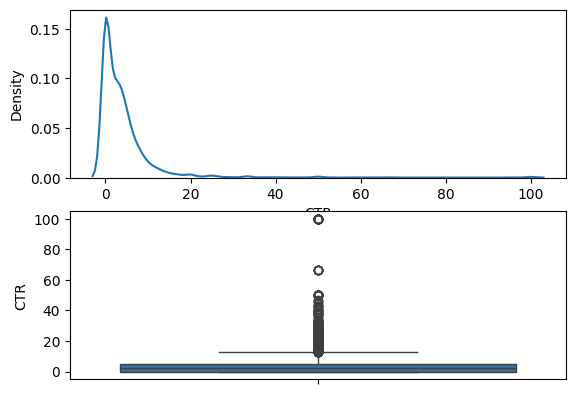

In [77]:
# KDE + boxplot to understand the shape of advertiser CTR distribution before choosing a threshold.
# We need to see whether mean, median, or a quantile makes the most sense as the high-CTR cutoff.
f, (ax1, ax2) = plt.subplots(2)
sns.kdeplot(temp['CTR'], ax=ax1)
sns.boxplot(x=None, y='CTR', data=temp, ax=ax2)
plt.show()

In [78]:
mean_advertiser_ctr = temp['CTR'].mean()
print('Average CTR of Ads given by an advertiser: ', round(mean_advertiser_ctr, 2))
median_advertiser_ctr = temp['CTR'].median()
print('Median CTR of Ads given by an advertiser: ', round(median_advertiser_ctr, 2))
third_quantile_advertiser_ctr = temp['CTR'].quantile(0.75)
print('3rd Quantile CTR of Ads given by an advertiser: ', round(third_quantile_advertiser_ctr, 2))

Average CTR of Ads given by an advertiser:  3.94
Median CTR of Ads given by an advertiser:  2.41
3rd Quantile CTR of Ads given by an advertiser:  5.13


Let us define 'High CTR Advertiser' as - an advertiser whose ad CTR > 3rd quantile Advertiser CTR

In [79]:
# Label advertisers above the 75th percentile CTR as 'high CTR' — top-quartile is a natural, robust cutoff.
temp['HighCTR'] = temp['CTR'] > third_quantile_advertiser_ctr
temp.head()

,AdvId,CTR,DCount,TCount,HighCTR
0,78,0.000000,2.000000,3.000000,False
1,80,0.000000,2.000000,3.000000,False
2,81,7.317073,26.000000,11.000000,True
3,82,3.693460,22.000000,5.000000,False
4,83,3.378378,17.783784,5.081081,False


In [80]:
temp['HighCTR'].value_counts()  # ~25% HighCTR as expected from the 75th-percentile definition

HighCTR
False    10457
True      3464
Name: count, dtype: int64

Out of 13921 Advertisers, only 3464 Advertisers have Ads. with CTR > 5.13 %.

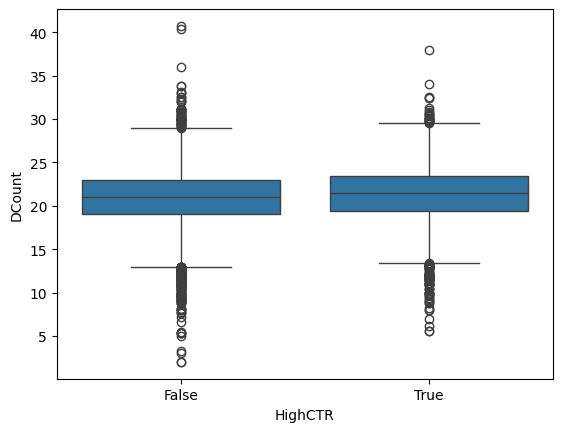

In [81]:
# Test if high-CTR advertisers write longer descriptions — more detail might build trust and lift clicks.
sns.boxplot(x='HighCTR', y='DCount', data=temp)
plt.show()

In [82]:
(temp[['HighCTR', 'DCount']].copy()).groupby('HighCTR').agg(['median'])

,DCount
,median
HighCTR,
False,21.023529
True,21.476378


Conclusion: Median no. of words in the description of an Ad for high CTR advertiser (21.47) is slightly more as compared to a low CTR advertiser(21.02).

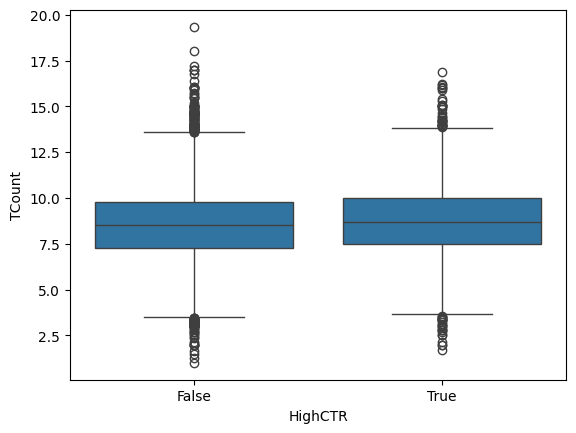

In [83]:
# Same test for title length — does more copy in the headline help high-CTR advertisers?
sns.boxplot(x='HighCTR', y='TCount', data=temp)
plt.show()

In [84]:
(temp[['HighCTR', 'TCount']].copy()).groupby('HighCTR').agg(['median'])

,TCount
,median
HighCTR,
False,8.5
True,8.7


Conclusion: Median no. of words in the title of an Ad for high CTR advertiser is slightly high (8.7) than a low CTR advertiser (8.5).

##### Takeaway:

Advertisers who have high CTRs use alomost same median no. of words in the title & description of their ads as an advertiser with low CTR which is intuitive. Why ? Because typically limited display space is given to every Ad irrespective of the Advertiser. Then why some Advertisers have High CTR ? 

There are various reasons we can think off:

1. High Quality content in Ads
2. Product sold by an Advertiser can have high demand when data was collected.

In [85]:
# Test if high-CTR advertisers are also heavier ad buyers (more impressions = more exposure).
# If frequency and CTR are correlated, impression count becomes a useful advertiser quality proxy.
interim = data[['AdvId', 'Impression']].copy()
interim.head()

,AdvId,Impression
0,385,1
1,37484,1
2,36759,1
3,23778,1
4,34535,1


In [86]:
# Sum gives total impressions; count gives number of training entries — two measures of advertiser frequency.
result = interim.groupby('AdvId').agg(['sum', 'count'])
result.head()

Impression      
             sum count
AdvId                 
78             1     1
80             1     1
81            98    82
82          5230  3651
83            63    37

How to intepret above figure ? Advertisements by Adv. Id 82 were displayed 5230 times across 3651 user queries.

In [87]:
# Attach impression and entry-count columns to the advertiser dataframe built above.
temp['Impression'] = result[('Impression', 'sum')].values
temp['Count']      = result[('Impression', 'count')].values
temp.head()

,AdvId,CTR,DCount,TCount,HighCTR,Impression,Count
0,78,0.000000,2.000000,3.000000,False,1,1
1,80,0.000000,2.000000,3.000000,False,1,1
2,81,7.317073,26.000000,11.000000,True,98,82
3,82,3.693460,22.000000,5.000000,False,5230,3651
4,83,3.378378,17.783784,5.081081,False,63,37


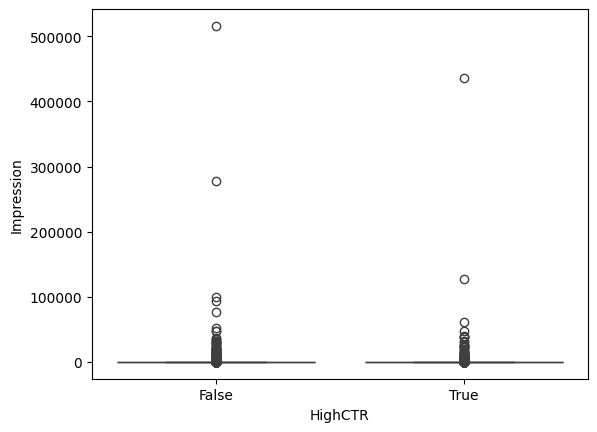

In [88]:
# Boxplot of total impressions by CTR group — outliers are expected given the heavy right tail.
sns.boxplot(x='HighCTR', y='Impression', data=temp)
plt.show()

Clearly there are outliers in data. Let us take 3rd quantile value to be robust in our estimate.

In [89]:
# Both mean and median reported — median is more robust to the heavy-tailed impression distribution.
(temp[['HighCTR', 'Impression']].copy()).groupby('HighCTR').agg(['mean', 'median'])

Impression       
               mean median
HighCTR                   
False    380.769245   53.0
True     589.980370   49.0

Conclusion: A High CTR Advertiser has higher avg. impressions(590.0) as opposed to a low CTR Advertiser (381.0). However median no. of impressions for a High CTR Advertiser is lower (49) as opposed to a low CTR Advertiser(53).

#### 3.2.2.2 : Studying the role of Advertiser based on Ad Frequency

We divide the data into two categories, each corr. to frequent & infrequent Advertisers.
Once we have divided the data,we can study how Ads by a frequent Advertiser differs from a infrequent Advertiser.
e.g. We can know if an frequent advertiser use more words to describe ad, more words in the ad title etc...

The burning question...
How to decide if an Advertiser is a frequent Advertiser or not?
There are two ways we can do this.. based on 1. Impression 2. Count
Advertiser Impression: total no. of impressions of all Ads by an Adv.
Advertiser Count: total no. training entries all Ads by an Adv.
We choose Advertiser Impression as a criteria for deciding if an Advertiser is frequent or not.
Let us study the distribution of Advertiser Impressions...

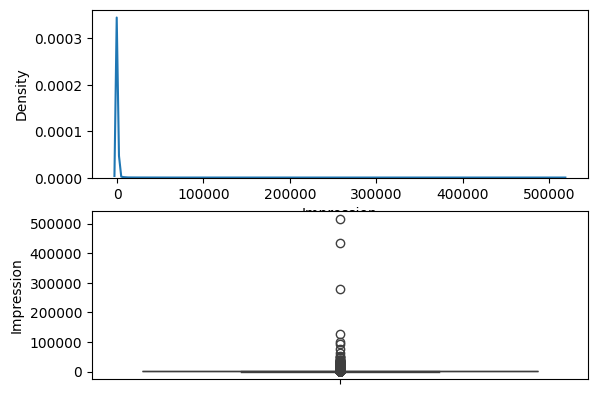

In [90]:
# KDE + boxplot for total impressions across advertisers — confirms heavy right skew before threshold choice.
f, (ax1, ax2) = plt.subplots(2)
sns.kdeplot(temp['Impression'], ax=ax1)
sns.boxplot(x=None, y='Impression', data=temp, ax=ax2)
plt.show()

In [91]:
mean_advertiser_impression = temp['Impression'].mean()
print('Average Advertiser Impression: ', round(mean_advertiser_impression, 2))
median_advertiser_impression = temp['Impression'].median()
print('Median Advertiser Impression: ', round(median_advertiser_impression, 2))
third_quantile_advertiser_impression = temp['Impression'].quantile(0.75)
print('3rd Quantile Advertiser Impression: ', round(third_quantile_advertiser_impression, 2))

Average Advertiser Impression:  432.83
Median Advertiser Impression:  51.0
3rd Quantile Advertiser Impression:  152.0


Let us define 'Frequent Advertiser' as - advertiser with Advertiser Impression > 3rd quantile Advertiser Impression.

In [92]:
# 'Frequent Advertiser' = entry count above the 3rd-quartile impression threshold.
# Using Count (entry rows) rather than raw sum avoids inflating by single high-impression sessions.
temp['IsFrequent'] = temp['Count'] > third_quantile_advertiser_impression
temp.head()

,AdvId,CTR,DCount,TCount,HighCTR,Impression,Count,IsFrequent
0,78,0.000000,2.000000,3.000000,False,1,1,False
1,80,0.000000,2.000000,3.000000,False,1,1,False
2,81,7.317073,26.000000,11.000000,True,98,82,False
3,82,3.693460,22.000000,5.000000,False,5230,3651,True
4,83,3.378378,17.783784,5.081081,False,63,37,False


In [93]:
temp['IsFrequent'].value_counts()  # ~25% frequent as expected from 75th-percentile threshold

IsFrequent
False    10887
True      3034
Name: count, dtype: int64

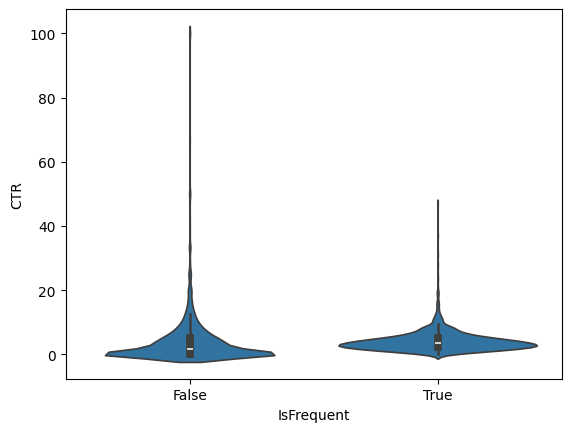

In [94]:
# Violin plot shows distribution shape on both sides — richer than a boxplot for comparing two groups.
sns.violinplot(x='IsFrequent', y='CTR', data=temp)
plt.show()

In [95]:
(temp[['IsFrequent', 'CTR']].copy()).groupby('IsFrequent').agg(['mean', 'median'])

CTR          
                mean    median
IsFrequent                    
False       3.889416  1.587302
True        4.144337  3.506866

Conclusion: A frequent advertiser has higher median CTR(3.51%) & avg. CTR(4.14%) as compared to an infrequent advertiser with 1.58% median CTR & 3.89% avg. CTR. Why it that ? This is very intuitive. How ? 

An Advertiser being frequent tantamounts to higher CTR else he/she wouldn't be frequent in the first place.
Why on earth would an advertiser want to show their Ads if more impressions isn't generating revenue for the advertiser.

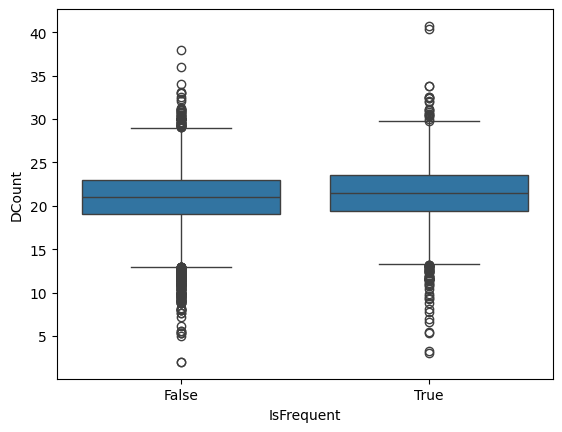

In [96]:
# Does frequent presence in ad auctions come with longer descriptions?
sns.boxplot(x='IsFrequent', y='DCount', data=temp)
plt.show()

In [97]:
(temp[['IsFrequent', 'DCount']].copy()).groupby('IsFrequent').agg(['median'])

,DCount
,median
IsFrequent,
False,21.000000
True,21.502765


Conclusion: Median no. of words in the Ad description for frequent advertiser is slightly high (21.5) than a infrequent advertiser(21.0).

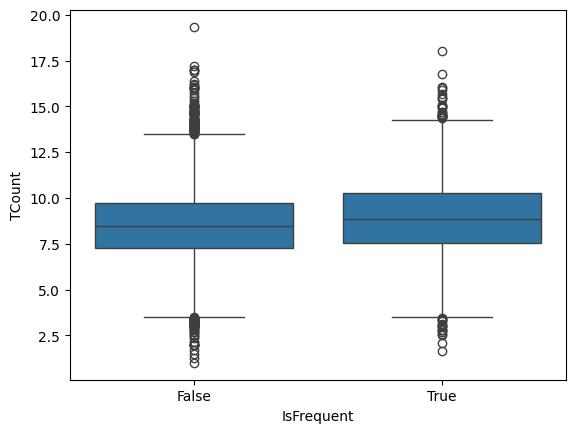

In [98]:
# Does frequent advertiser also write longer titles?
sns.boxplot(x='IsFrequent', y='TCount', data=temp)
plt.show()

In [99]:
(temp[['IsFrequent', 'TCount']].copy()).groupby('IsFrequent').agg(['median'])

,TCount
,median
IsFrequent,
False,8.446429
True,8.872962


Conclusion: Median no. of words in the Ad Title for frequent advertiser is slightly high (8.9) than a infrequent advertiser(8.4).

### Ad-Level CTR and Frequency Analysis

We repeat the advertiser analysis at the individual ad level. Ads are grouped into high-CTR and frequent categories and we compare their text length, impression counts, and CTR distributions. If the advertiser-level patterns also hold at the ad level, it justifies building both advertiser-level and ad-level historical CTR features in the modelling notebook.

We divide the data into two categories, one corr. to Ads with high CTR & other corr. to Ads with low CTR.
Once this is done, we can investigate how an Ad with high CTR differs from an Ad with low CTR.

What is my goal ? To study properties of Advertisements.
What questions I intend to answer ?
1. How does no. of words in Ad Description vary with CTR of an Ad ?
2. How does no. of words in Ad Title vary with CTR of an Ad ?
3. How is the Ad frequency related to no. of words used in Ad description ?
4. How is the Ad frequency related to no. of words used in Ad title ?
5. How is the Ad frequency related to Ad Position ?
6. How is the Ad frequency related to Ad Depth ?
7. How is the Ad frequency related to Ad Clicks ? Does more Ad impressions mean more clicks ?
8. Does frequency of an Ad has an effect on CTR of the Ad ?

In [100]:
# Build an ad-level view by aggregating position, depth, and text lengths per unique ad.
# This collapses multiple training rows for the same ad into one representative profile.
temp = data[['AdId', 'CTR', 'Pos', 'Depth', 'QCount', 'DCount', 'TCount']].copy()

In [101]:
# Per-ad averages across all query sessions where the ad appeared.
result = temp.groupby('AdId').agg(['mean'])
result.head()

,CTR,Pos,Depth,QCount,DCount,TCount
,mean,mean,mean,mean,mean,mean
AdId,,,,,,
1000031,0.000000,2.000000,2.000000,5.000000,18.000000,6.0
1000467,6.578947,1.947368,2.052632,2.421053,17.947368,5.0
1000468,0.000000,1.000000,2.000000,1.000000,17.000000,5.0
1000469,0.000000,2.000000,2.000000,2.000000,17.000000,5.0
1000471,0.000000,1.500000,1.750000,2.625000,17.875000,5.0


In [102]:
# Flatten multi-index into a clean ad-level dataframe for per-ad analysis.
temp = pd.DataFrame()
temp['AdId']   = result.index
temp['CTR']    = result[('CTR', 'mean')].values
temp['Pos']    = result[('Pos', 'mean')].values
temp['Depth']  = result[('Depth', 'mean')].values
temp['DCount'] = result[('DCount', 'mean')].values
temp['TCount'] = result[('TCount', 'mean')].values
temp.head()

,AdId,CTR,Pos,Depth,DCount,TCount
0,1000031,0.000000,2.000000,2.000000,18.000000,6.0
1,1000467,6.578947,1.947368,2.052632,17.947368,5.0
2,1000468,0.000000,1.000000,2.000000,17.000000,5.0
3,1000469,0.000000,2.000000,2.000000,17.000000,5.0
4,1000471,0.000000,1.500000,1.750000,17.875000,5.0


In [103]:
# Sum total clicks and impressions per ad — cumulative sums are more meaningful than row-level means here.
interim = data[['AdId', 'Impression', 'Click']].copy()
iresult = interim.groupby('AdId').agg(['sum'])
iresult.head()

,Impression,Click
,sum,sum
AdId,,
1000031,1,0
1000467,44,2
1000468,1,0
1000469,1,0
1000471,8,0


In [104]:
temp['Impression'] = iresult[('Impression', 'sum')].values
temp['Click']      = iresult[('Click', 'sum')].values
temp.head()

,AdId,CTR,Pos,Depth,DCount,TCount,Impression,Click
0,1000031,0.000000,2.000000,2.000000,18.000000,6.0,1,0
1,1000467,6.578947,1.947368,2.052632,17.947368,5.0,44,2
2,1000468,0.000000,1.000000,2.000000,17.000000,5.0,1,0
3,1000469,0.000000,2.000000,2.000000,17.000000,5.0,1,0
4,1000471,0.000000,1.500000,1.750000,17.875000,5.0,8,0


In [105]:
print('No. of unique advertisements: ', temp.shape[0])

No. of unique advertisements:  212422


The burning question...
How to decide if an Ad qualifies as a high CTR Advertisment ?
Let us study the distribution of avg. Ad CTRs...

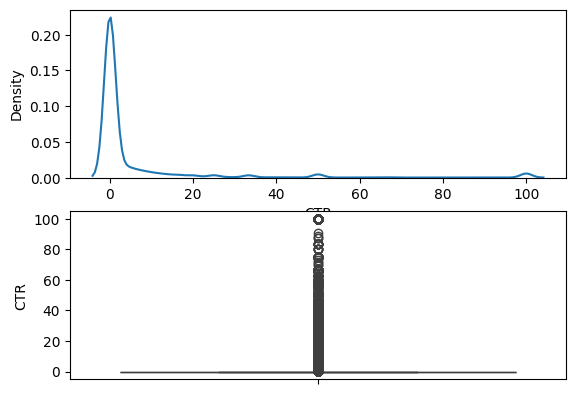

In [106]:
# KDE + boxplot for ad CTR distribution — need to see where median and mean lie before choosing threshold.
# High right-skew (many zero-CTR ads) means the median will be near zero, pushing us to use the mean.
f, (ax1, ax2) = plt.subplots(2)
sns.kdeplot(temp['CTR'], ax=ax1)
sns.boxplot(x=None, y='CTR', data=temp, ax=ax2)
plt.show()

In [107]:
mean_ad_ctr = temp['CTR'].mean()
print('Average CTR of Ads: ', round(mean_ad_ctr, 2))
median_ad_ctr = temp['CTR'].median()
print('Median CTR of Ads: ', round(median_ad_ctr, 2))
third_quantile_ad_ctr = temp['CTR'].quantile(0.75)
print('3rd Quantile CTR of Ads: ', round(third_quantile_ad_ctr, 2))

Average CTR of Ads:  5.01
Median CTR of Ads:  0.0
3rd Quantile CTR of Ads:  0.0


Since median & 3rd quantile avg. CTR is 0.0 using it as a threshold is meaningless. So, let us use
Avg. Ad CTR as a threshold for deciding if an ad is qualified as a high CTR ad or not.

In [108]:
# Mean is used as threshold because both median and 3rd quartile are 0.0 — the distribution is extremely right-skewed.
# Mean at least separates zero-CTR ads from those with any meaningful engagement.
temp['HighCTR'] = temp['CTR'] > mean_ad_ctr
temp.head()

,AdId,CTR,Pos,Depth,DCount,TCount,Impression,Click,HighCTR
0,1000031,0.000000,2.000000,2.000000,18.000000,6.0,1,0,False
1,1000467,6.578947,1.947368,2.052632,17.947368,5.0,44,2,True
2,1000468,0.000000,1.000000,2.000000,17.000000,5.0,1,0,False
3,1000469,0.000000,2.000000,2.000000,17.000000,5.0,1,0,False
4,1000471,0.000000,1.500000,1.750000,17.875000,5.0,8,0,False


In [109]:
temp['HighCTR'].value_counts()  # imbalance expected — most ads have near-zero CTR

HighCTR
False    177184
True      35238
Name: count, dtype: int64

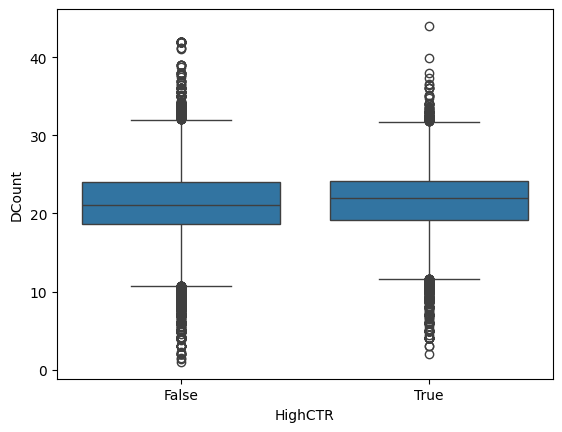

In [110]:
# High-CTR ads tend to have longer descriptions — more copy may signal more persuasive or relevant creative.
sns.boxplot(x='HighCTR', y='DCount', data=temp)
plt.show()

In [111]:
(temp[['HighCTR', 'DCount']].copy()).groupby('HighCTR').agg(['median'])

,DCount
,median
HighCTR,
False,21.111111
True,22.000000


Conclusion: Description of an Ad with high CTR typically has a higher median no. of words (22.0) as compared to a low CTR Ad (21.1).

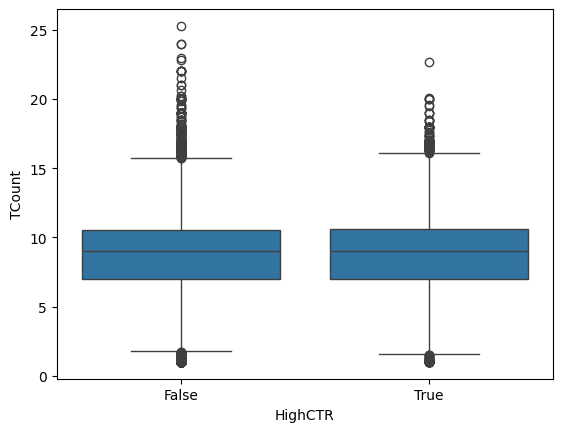

In [112]:
# Title length vs CTR — checking whether high-CTR ads use more or fewer title words.
sns.boxplot(x='HighCTR', y='TCount', data=temp)
plt.show()

In [113]:
(temp[['HighCTR', 'TCount']].copy()).groupby('HighCTR').agg(['median'])

,TCount
,median
HighCTR,
False,9.0
True,9.0


Conclusion: Title of an Ad with high CTR typically has equal median no. of words (9.0) as a low CTR Ad.

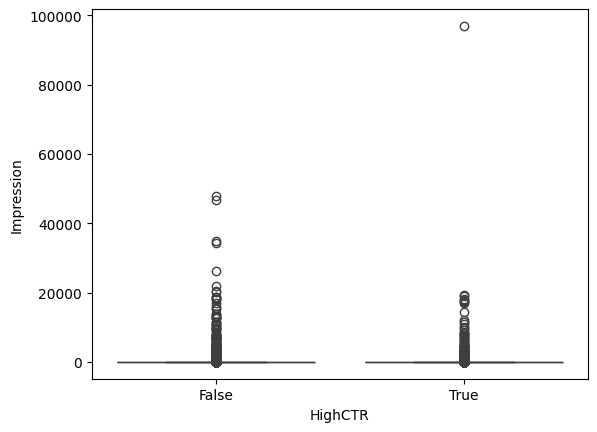

In [114]:
# Test if high-CTR ads also accumulate more impressions.
# The causal arrow could go either way: CTR drives the ranking system to show the ad more, inflating impressions.
sns.boxplot(x='HighCTR', y='Impression', data=temp)
plt.show()

In [115]:
(temp[['HighCTR', 'Impression']].copy()).groupby('HighCTR').agg(['mean', 'median'])

Impression       
              mean median
HighCTR                  
False    23.909360    3.0
True     50.770191    9.0

Conclusion: A High CTR Ad has higher avg. impressions(50.8) & median impressions(9.0) as opposed to a low CTR Ad with avg. impressions of 23.90 & median impressions of 3.0

Part 3.2 Studying Ad properties based on Ad frequency...

The burning question...
How to decide if an Ad is frequent or not?
There are two ways we can do this.. based on 1. Impression 2. Count
Ad Impression: total no. of impressions of an Ad across all entries in the training file.
Ad Count: total no. of training entries in which Ad appeared.
We choose Ad Impression as a criteria for deciding if an Ad is frequent or not.
Let us study the distribution of Ad Impressions...

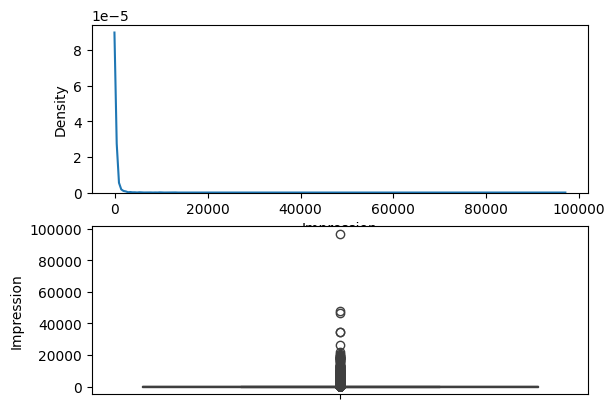

In [116]:
# KDE + boxplot for total impressions per ad — heavy right skew expected (a few ads dominate exposure).
f, (ax1, ax2) = plt.subplots(2)
sns.kdeplot(temp['Impression'], ax=ax1)
sns.boxplot(x=None, y='Impression', data=temp, ax=ax2)
plt.show()

In [117]:
mean_ad_impression = temp['Impression'].mean()
print('Avg. impressions of an Ad: ', round(mean_ad_impression))
median_ad_impression = temp['Impression'].median()
print('Median impressions of an Ad: ', round(median_ad_impression))
third_quantile_ad_impression = temp['Impression'].quantile(0.75)
print('3rd quartile impressions of an Ad: ', round(third_quantile_ad_impression))

Avg. impressions of an Ad:  28
Median impressions of an Ad:  3
3rd quartile impressions of an Ad:  10


Let us define 'Frequent Ad' as - an Ad with Ad Impression > 3rd quantile Ad Impression.

In [118]:
# Label ads above the 75th-percentile impression count as 'frequent' — top quartile by exposure volume.
temp['IsFrequent'] = temp['Impression'] > third_quantile_ad_impression
temp.head()

,AdId,CTR,Pos,Depth,DCount,TCount,Impression,Click,HighCTR,IsFrequent
0,1000031,0.000000,2.000000,2.000000,18.000000,6.0,1,0,False,False
1,1000467,6.578947,1.947368,2.052632,17.947368,5.0,44,2,True,True
2,1000468,0.000000,1.000000,2.000000,17.000000,5.0,1,0,False,False
3,1000469,0.000000,2.000000,2.000000,17.000000,5.0,1,0,False,False
4,1000471,0.000000,1.500000,1.750000,17.875000,5.0,8,0,False,False


In [119]:
temp['IsFrequent'].value_counts()  # near-balanced split because we're using the 75th percentile

IsFrequent
False    160853
True      51569
Name: count, dtype: int64

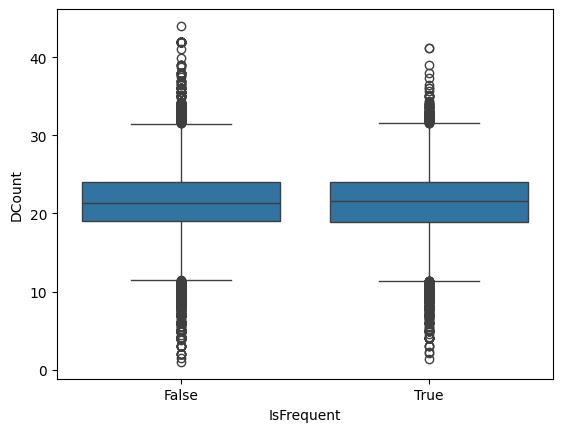

In [120]:
# Check if frequently shown ads use longer descriptions — a sign of advertiser investment in quality.
sns.boxplot(x='IsFrequent', y='DCount', data=temp)
plt.show()

In [121]:
(temp[['IsFrequent', 'DCount']].copy()).groupby('IsFrequent').agg(['median'])

,DCount
,median
IsFrequent,
False,21.285714
True,21.608696


Conclusion: Description of a frequent Ad has a slightly higher median no. of words (21.6) as compared to a infrequent Ad (21.3).

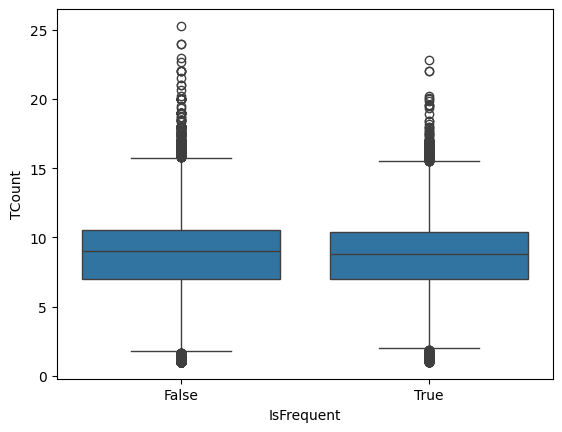

In [122]:
# Check if frequent ads also use longer titles — consistent with description pattern would be meaningful.
sns.boxplot(x='IsFrequent', y='TCount', data=temp)
plt.show()

In [123]:
(temp[['IsFrequent', 'TCount']].copy()).groupby('IsFrequent').agg(['median'])

,TCount
,median
IsFrequent,
False,9.000000
True,8.764706


Conclusion: Title of a frequent Ad has a almost equal median no. of words (8.8) as compared to a infrequent Ad (9.0).

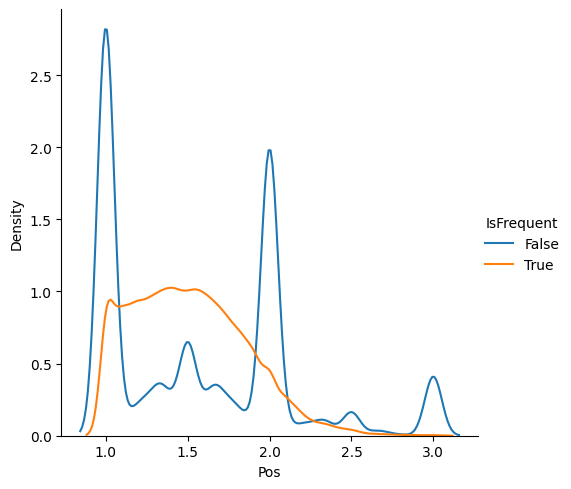

In [124]:
# KDE of ad positions by frequency group — checks if frequently shown ads occupy premium positions.
# If so, position is partially confounded with frequency.
sns.FacetGrid(temp, hue="IsFrequent", height=5) \
   .map(sns.kdeplot, "Pos") \
   .add_legend()
plt.show()

Conclusion: infrequent & frequenct ads usually occupy similar positions which is mostly positions 1 & 2.

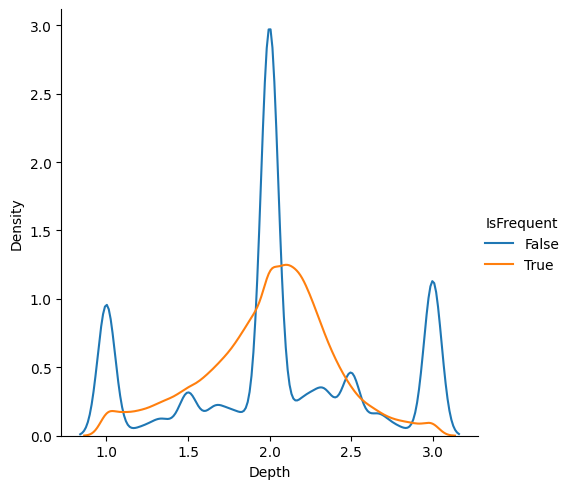

In [125]:
# KDE of session depth by frequency group — deeper sessions may indicate niche or competitive placements.
sns.FacetGrid(temp, hue="IsFrequent", height=5) \
   .map(sns.kdeplot, "Depth") \
   .add_legend()
plt.show()

Conclusion: infrequent advertisement occur mostly in search sessions with depths is 2. On the other hand occurence of a frequent advertisement is distributed normally (not exactly) across all depths.

Conclusion: If an advertisement is infrequent it has less no. of clicks as compared to an frequent advertisement. 
Why is that ? It is very intuitive. How ? Ad is infrequent in the first place becuase it has low CTR hence low no. of clicks.

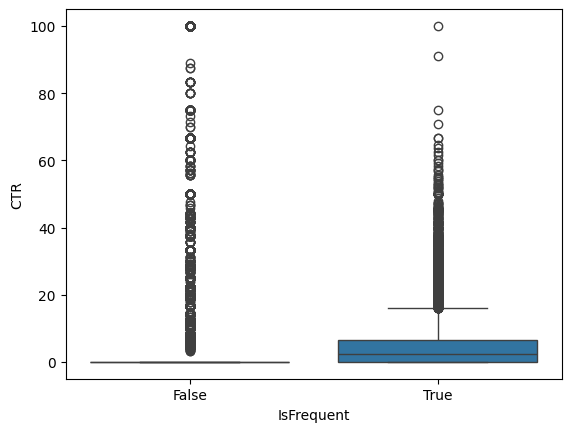

In [126]:
# Boxplot of CTR by frequency — do frequently shown ads earn higher CTRs?
# Outliers are expected; median is the reliable comparison statistic here.
sns.boxplot(x='IsFrequent', y='CTR', data=temp)
plt.show()

In [127]:
# Median CTR is the right metric here — CTR is heavily right-skewed and the mean is dominated by outliers.
(temp[['IsFrequent', 'CTR']].copy()).groupby('IsFrequent').agg(['median'])

,CTR
,median
IsFrequent,
False,0.000000
True,2.362205


Frequent Ads have higher median CTR (2.36) as opposed to infrequent Ads (0.0) which is intuitive.

In [128]:
# Key takeaways that directly motivate the feature engineering choices in notebook 02:
# 1. Lower position → higher CTR → feature: mean position CTR (mPosCTR)
# 2. Frequent advertisers → higher CTR → feature: mean advertiser CTR (mAdvCTR)
# 3. Frequent ads → higher CTR → feature: mean ad CTR (mAdCTR)
# These historical CTR signals form the backbone of the predictive model.

## Summary of EDA Findings

| Feature | Finding | Model Relevance |
|---|---|---|
| Ad Position | Lower position (closer to 1) → much higher CTR | **Strong** — position-level mean CTR feature |
| Session Depth | Depth 3 → lower CTR than depth 1 or 2 | **Moderate** — depth-level mean CTR feature |
| Advertiser CTR | Top-quartile advertisers consistently outperform | **Strong** — advertiser historical CTR feature |
| Ad Frequency | Frequently shown ads have higher median CTR | **Moderate** — ad historical CTR feature |
| User Gender | No meaningful CTR difference across genders overall | **Weak** — exclude unless combined with age |
| User Age | Users aged 30+ (groups 5 and 6) have the highest CTR at 4.75% and 5.26%. Ages 18–30 (groups 3 and 4) click *less* than even the youngest cohort — CTR does not increase monotonically with age. Within the 30+ group, female users outperform male (5.03% vs 4.81%). | **Moderate** — age×gender interaction |
| Query Length | CTR peaks at 3-word queries (4.90%) and declines at both extremes — very short queries are too ambiguous, very long queries are too specific | **Weak** — auxiliary feature at best |
| Ad Description Length | Marginal difference for high-CTR ads | **Weak** signal on its own |
| Ad Title Length | No consistent CTR pattern by title length | **Exclude** from primary model |
| Impressions vs Clicks | High impressions do not guarantee high clicks | CTR (ratio) matters, not raw click volume |

**Key insight:** The strongest signals are structural (position, depth) and historical (advertiser CTR, ad CTR). Text-length features carry weak signal and should be used cautiously. This directly motivates the pseudo-CTR feature engineering approach in notebook 02.

## What I Learned

1. **Position is the dominant CTR driver.** Ads in position 1 have dramatically higher CTR than those in positions 2 or 3. This isn't surprising, but the magnitude is striking — it means the ranking algorithm itself is a confound in any CTR model trained on observational data. A model that doesn't account for position will learn position bias, not ad quality.

2. **Session depth creates attention fatigue.** CTR drops noticeably when session depth reaches 3, suggesting users are more likely to click early in a session when their intent is fresh. This is the kind of contextual signal that is invisible in cross-sectional analyses but becomes obvious once you slice by depth.

3. **Users aged 30+ show the highest CTR, but the relationship is not monotonic.** Ages 18–30 (groups 3 and 4) actually click *less* than even the youngest cohort (under 18). Only groups 5 (30–40) and 6 (>40) clearly outperform the rest. Within the 30+ group, women outperform men at 5.03% vs 4.81%. This is a reminder that slicing by age alone can mask the real pattern — the signal lives in the tails of the age distribution, not in a smooth gradient.

4. **Historical CTR is far more predictive than ad text features.** Word count of titles and descriptions showed almost no consistent relationship with CTR, while advertiser-level and ad-level historical CTR showed clear stratification between high and low performers. This told me early on that the model should be built around past performance features, not content features.

5. **The impression–click scatter confirmed that volume ≠ quality.** Many high-impression ads had near-zero click counts, which means raw exposure doesn't translate to engagement. This supports using CTR (a ratio) rather than click count as both the target and as historical features.

6. **The dataset is extremely sparse at the per-ad level.** Many ads appear in only a handful of training rows, meaning their historical CTR estimates will be noisy. This motivated the use of smoothed pseudo-CTR estimates in the feature engineering step of notebook 02 rather than raw historical averages.